<a href="https://www.kaggle.com/code/roaahussein/eog-based-calculator?scriptVersionId=317439359" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend ,resample
from statsmodels.tsa.ar_model import AutoReg
from scipy.signal import find_peaks
from scipy.integrate import simpson
from scipy.signal import periodogram
import pywt
import os

In [2]:
data_path = '3-class'


In [3]:
def plot_eog_channels(data_dict, step_title):
    """
    Function to plot Horizontal and Vertical channels for all classes.
    data_dict: Dictionary containing {label: [h_signal, v_signal]}
    step_title: String title for the entire plot
    """
    fig, axes = plt.subplots(len(data_dict), 2, figsize=(15, 20))
    fig.suptitle(step_title, fontsize=16)
    
    for i, (label, signals) in enumerate(data_dict.items()):
        h_signal, v_signal = signals[0], signals[1]
        
        # Plot Horizontal (H)
        axes[i, 0].plot(h_signal, color='blue')
        axes[i, 0].set_title(f'{label} - Horizontal (H)')
        axes[i, 0].grid(True)
        
        # Plot Vertical (V)
        axes[i, 1].plot(v_signal, color='red')
        axes[i, 1].set_title(f'{label} - Vertical (V)')
        axes[i, 1].grid(True)
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Plot a signal from each class 

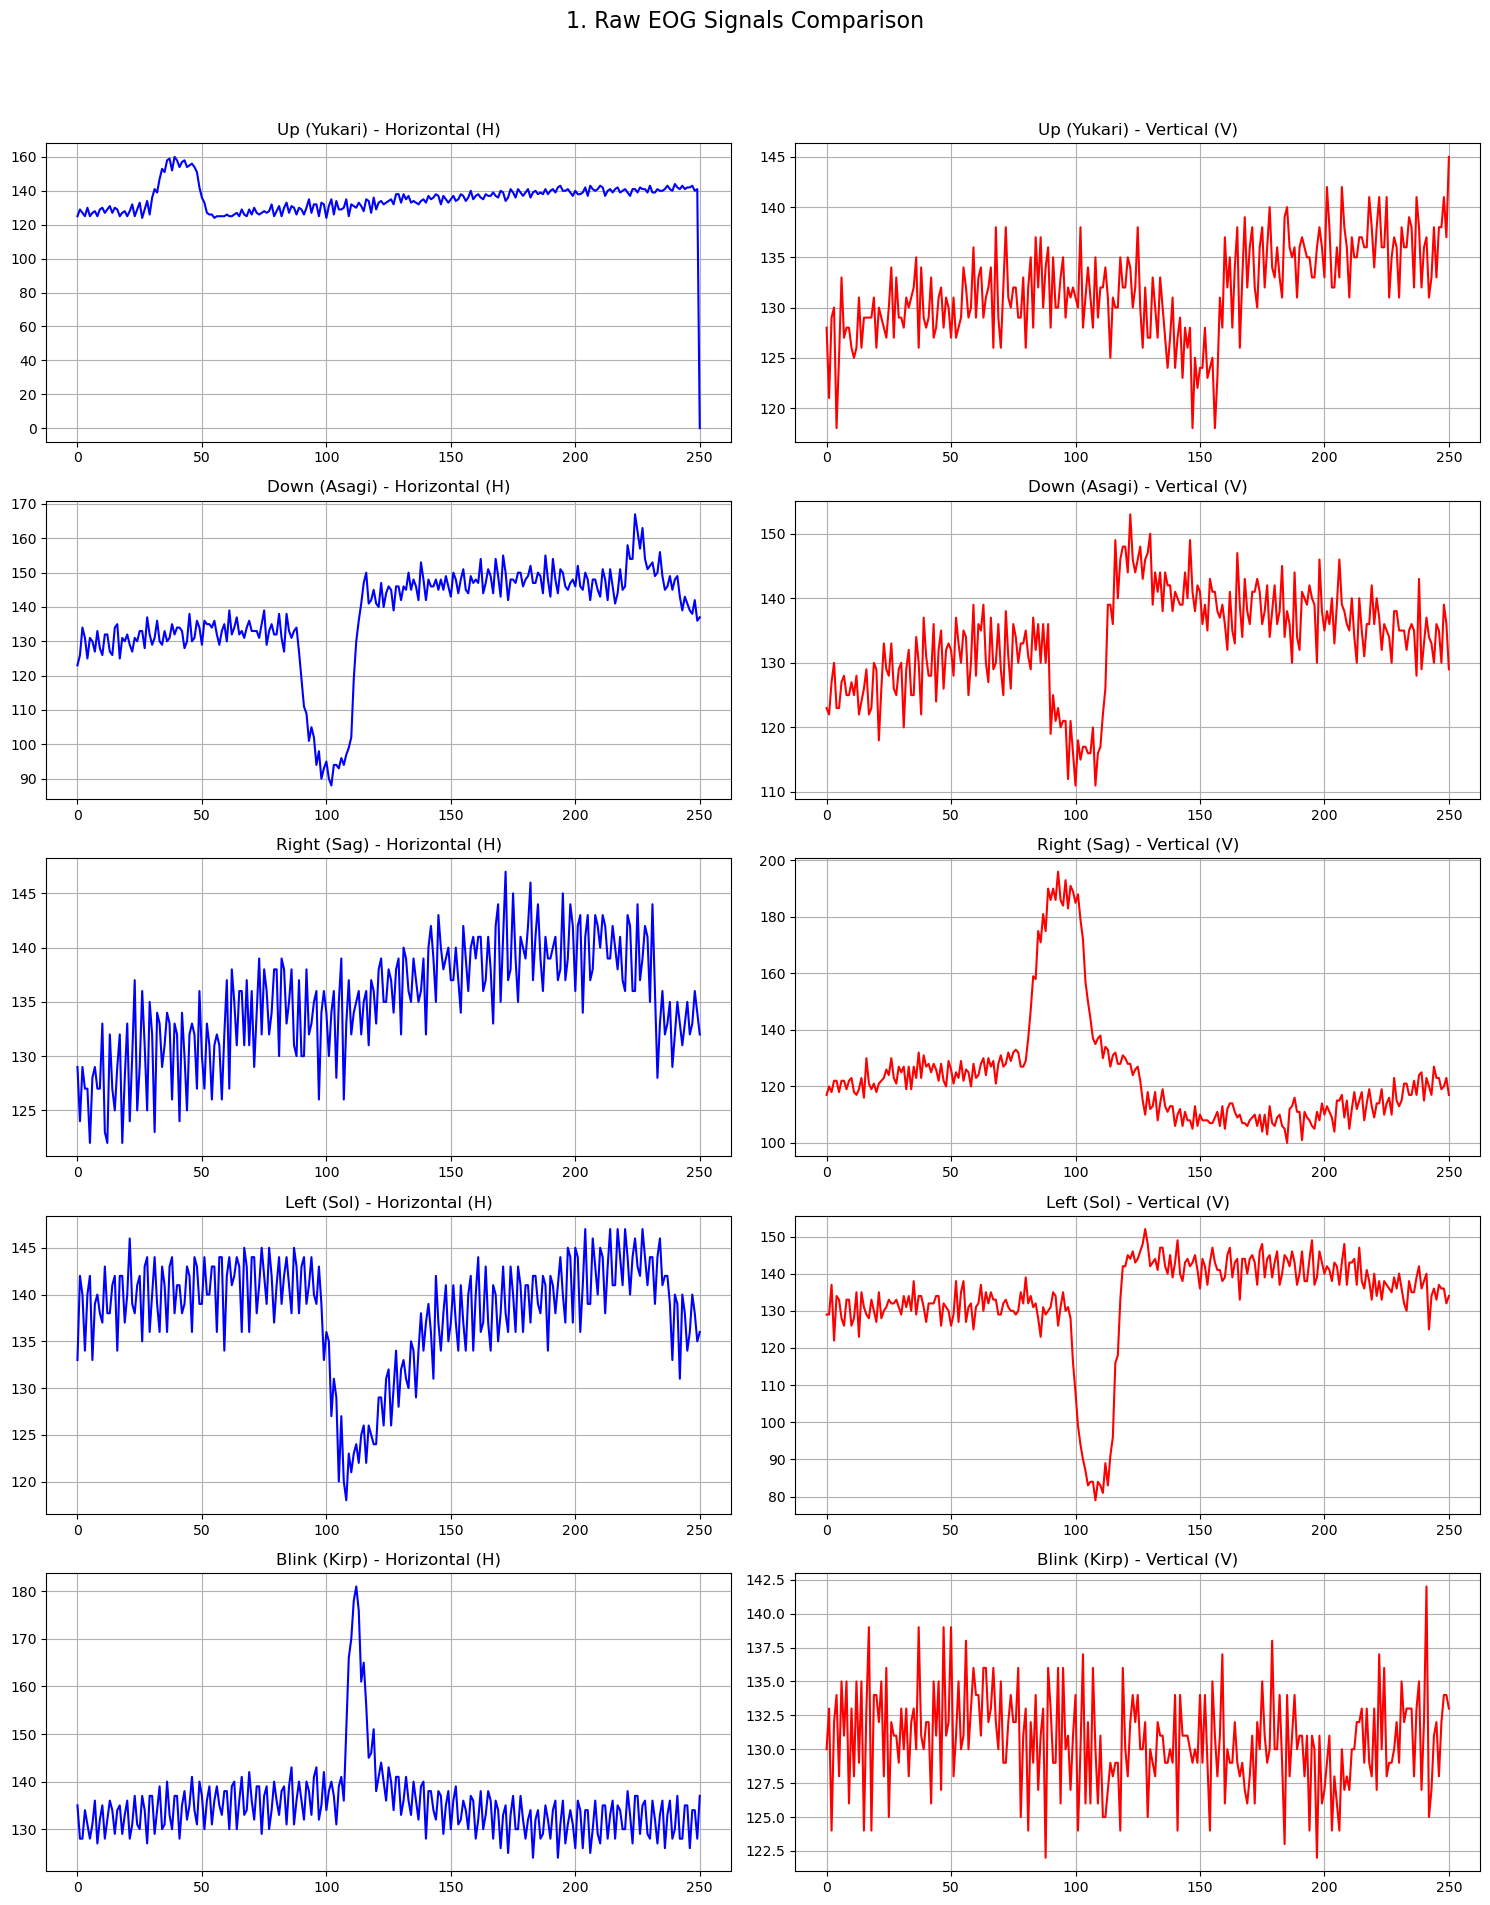

In [4]:
# Initial sample files mapping
samples_map = {
    'Up (Yukari)': ('yukari10h.txt', 'yukari10v.txt'),
    'Down (Asagi)': ('asagi10h.txt', 'asagi10v.txt'),
    'Right (Sag)': ('sag10h.txt', 'sag10v.txt'),
    'Left (Sol)': ('sol10h.txt', 'sol10v.txt'),
    'Blink (Kirp)': ('kirp10h.txt', 'kirp10v.txt')
}

# Load Raw Data into a Dictionary
current_data = {}
for label, files in samples_map.items():
    h_sig = np.loadtxt(os.path.join(data_path, files[0]))
    v_sig = np.loadtxt(os.path.join(data_path, files[1]))
    current_data[label] = [h_sig, v_sig]

# Plot Raw
plot_eog_channels(current_data, "1. Raw EOG Signals Comparison")

In [5]:
# 1. Digital Bandpass Filter
def apply_bandpass(signal, fs=176, low=0.5, high=20.0):
    # Filters out high-frequency muscle noise and low-frequency drift
    nyq = 0.5 * fs
    low_cut = low / nyq
    high_cut = high / nyq
    b, a = butter(4, [low_cut, high_cut], btype='band')
    return filtfilt(b, a, signal)

# # 2. Amplitude Normalization
# def apply_normalization(signal):
#     # Z-score normalization to ensure fair feature weight during classification
#     return (signal - np.mean(signal)) / np.std(signal)

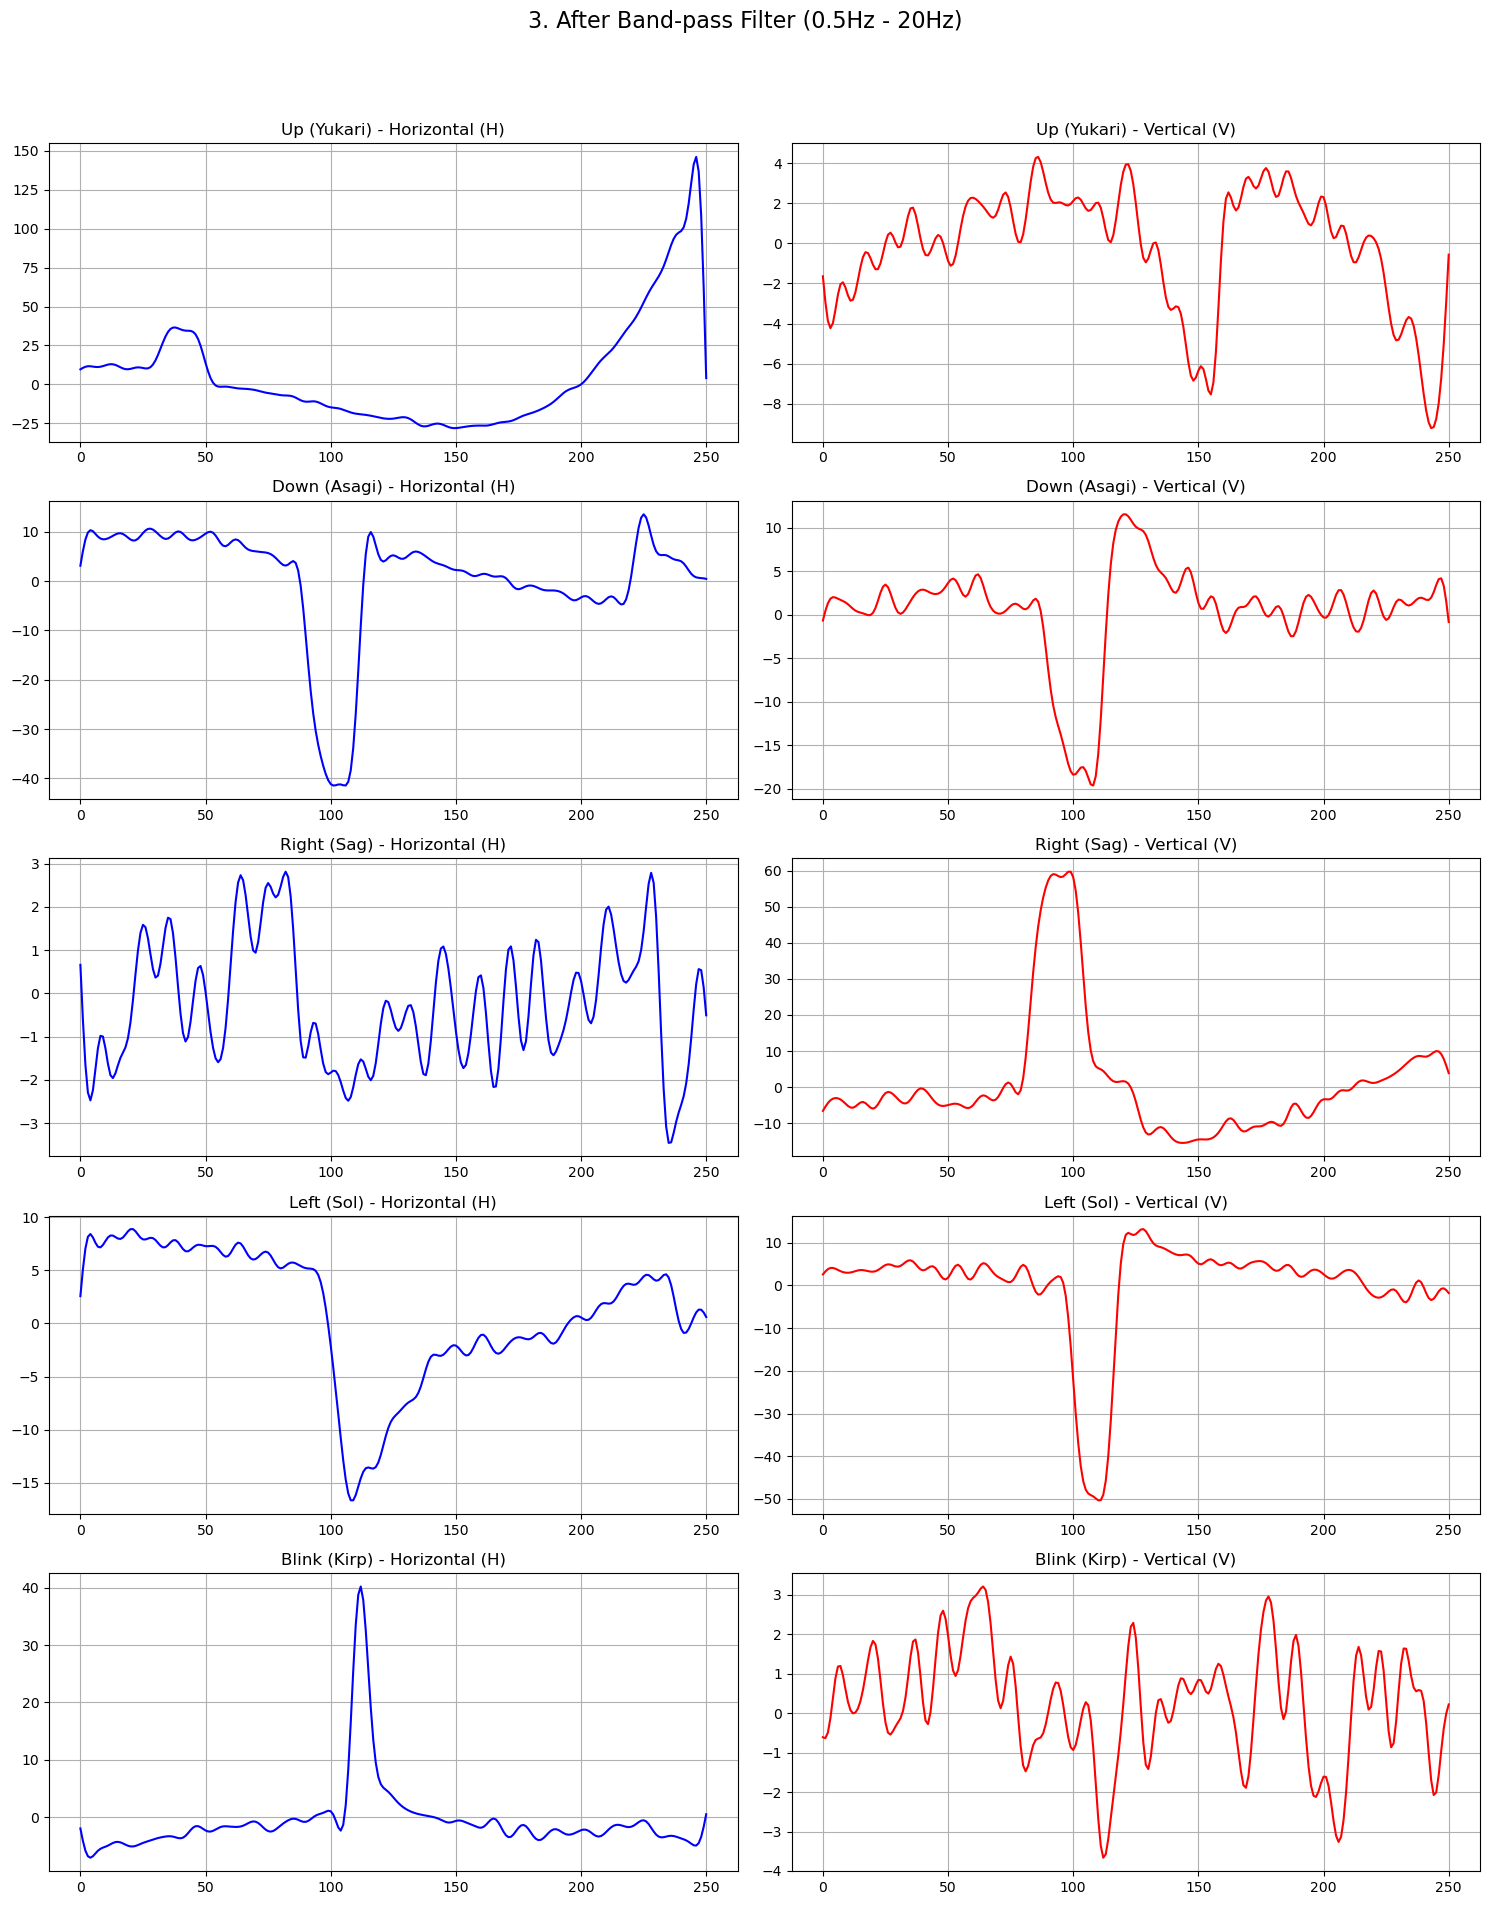

In [6]:
# Apply Filter
for label in current_data:
    current_data[label] = [apply_bandpass(sig) for sig in current_data[label]]

# Plot after Filtering
plot_eog_channels(current_data, "3. After Band-pass Filter (0.5Hz - 20Hz)")

In [7]:
# # Apply Normalization
# for label in current_data:
#     current_data[label] = [apply_normalization(sig) for sig in current_data[label]]
# plot_eog_channels(current_data, "5. After Normalization (Final Scaled Data)")

# Final Dataset Preparation

In [8]:
# Class label mapping
CLASS_MAP = {
    'yukari': 0,  # Up
    'asagi':  1,  # Down
    'sag':    2,  # Right
    'sol':    3,  # Left
    'kirp':   4,  # Blink
}

def preprocess_signal(signal, fs=176):
    """Full preprocessing pipeline: Bandpass -> Normalization"""
    signal = apply_bandpass(signal, fs=fs)
    # signal = apply_normalization(signal)
    return signal

def load_all_data(data_path, class_map):
    """
    Loads all recordings for all classes.
    Returns:
        raw_signals_H: np.array of shape (n_trials, 251) -- raw H channel per trial
        raw_signals_V: np.array of shape (n_trials, 251) -- raw V channel per trial
        signals_H: np.array of shape (n_trials, 251) -- preprocessed H channel per trial
        signals_V: np.array of shape (n_trials, 251) -- preprocessed V channel per trial
        y:         np.array of shape (n_trials,)     -- class label per trial
    """
    raw_signals_H, raw_signals_V, signals_H, signals_V, y = [], [], [], [], []

    for cls_name, cls_label in class_map.items():
        idx = 1
        while True:
            h_file = os.path.join(data_path, f'{cls_name}{idx}h.txt')
            v_file = os.path.join(data_path, f'{cls_name}{idx}v.txt')

            if not os.path.exists(h_file) or not os.path.exists(v_file):
                break  # No more recordings for this class

            h_raw = np.loadtxt(h_file)
            v_raw = np.loadtxt(v_file)

            h_proc = preprocess_signal(h_raw)
            v_proc = preprocess_signal(v_raw)

            raw_signals_H.append(h_raw)
            raw_signals_V.append(v_raw)
            signals_H.append(h_proc)
            signals_V.append(v_proc)
            y.append(cls_label)

            idx += 1

        print(f'{cls_name}: loaded {idx-1} recordings')

    return np.array(raw_signals_H), np.array(raw_signals_V), np.array(signals_H), np.array(signals_V), np.array(y)


raw_signals_H, raw_signals_V, signals_H, signals_V, y = load_all_data(data_path, CLASS_MAP)

print(f'\nFinal dataset shape:')
print(f'  signals_H: {signals_H.shape}  --> {signals_H.shape[0]} trials x 251 H timepoints')
print(f'  signals_V: {signals_V.shape}  --> {signals_V.shape[0]} trials x 251 V timepoints')
print(f'  y:         {y.shape}          --> labels (0=Up, 1=Down, 2=Right, 3=Left, 4=Blink)')
print(f'\nSamples per class: {dict(zip(CLASS_MAP.keys(), [np.sum(y==v) for v in CLASS_MAP.values()]))}')

# Save for Feature Extraction notebook
np.save('signals_H.npy', signals_H)
np.save('signals_V.npy', signals_V)
np.save('y_labels.npy',  y)
print('\nSaved: signals_H.npy, signals_V.npy, y_labels.npy')

yukari: loaded 20 recordings
asagi: loaded 20 recordings
sag: loaded 20 recordings
sol: loaded 20 recordings
kirp: loaded 20 recordings

Final dataset shape:
  signals_H: (100, 251)  --> 100 trials x 251 H timepoints
  signals_V: (100, 251)  --> 100 trials x 251 V timepoints
  y:         (100,)          --> labels (0=Up, 1=Down, 2=Right, 3=Left, 4=Blink)

Samples per class: {'yukari': np.int64(20), 'asagi': np.int64(20), 'sag': np.int64(20), 'sol': np.int64(20), 'kirp': np.int64(20)}

Saved: signals_H.npy, signals_V.npy, y_labels.npy


# Raw Features

In [9]:
# Raw Features 
X_raw = np.concatenate([signals_H, signals_V], axis=1)  # (100, 502)

# Feature Extraction

In [10]:
def extract_mix_features(signal):
    """
    Extracts a combination of Morphological and Statistical features 
    from the time domain signal.
    """
    # --- Morphological Features ---
    peaks, _ = find_peaks(signal)
    if len(peaks) > 0:
        max_peak = np.max(signal[peaks])
    else:
        max_peak = np.max(signal)
        
    # Calculate Area Under the Curve (AUC) using Simpson's rule
    area = simpson(signal)
    
    # --- Statistical Features ---
    mu = np.mean(signal)
    # Calculate the variance (measure of signal spread)
    var = np.var(signal)
    std = np.std(signal)
    
    return [max_peak, area, mu, var, std]

In [11]:
def extract_wavelet_features(signal):
    """
    Fs = 176 Hz, Level = 2.
    Extracts cA2 coefficients covering the 0-22 Hz range.
    """
    coeffs = pywt.wavedec(signal, 'db1', level=2)
    wavelet_features = coeffs[0]
    
    return wavelet_features

In [12]:
def extract_ar_features(signal, lags=10):
    from scipy.signal import detrend
    import numpy as np
    from statsmodels.tsa.ar_model import AutoReg
    
    # preprocess
    signal = detrend(signal)
    std = np.std(signal)
    
    # avoid division by zero
    if std == 0:
        return np.zeros(lags + 1)
    
    signal = (signal - np.mean(signal)) / std
    
    # AR model
    model = AutoReg(signal, lags=lags).fit()
    
    # coefficients فقط
    coeffs = model.params[1:]
    
    return coeffs

In [13]:
def extract_psd_features(signal, fs=176):
    """
    Computes the Power Spectral Density (PSD) using the Periodogram method.
    Returns the power values for each frequency.
    """
    f, Pxx = periodogram(signal, fs, scaling='density')
    relevant_indices = np.where(f <= 40)[0]
    psd_features = Pxx[relevant_indices]
    
    return psd_features

In [14]:
def extract_ar_features2(signal, lags=10):
    from scipy.signal import detrend
    import numpy as np
    from statsmodels.tsa.ar_model import AutoReg
    
    signal = detrend(signal)
    std = np.std(signal)
    
    if std == 0:
        return np.zeros(lags)
    
    signal = (signal - np.mean(signal)) / std
    
    model = AutoReg(signal, lags=lags).fit()
    
    return model.params  

In [15]:
def prepare_data_for_svm(raw_signals_H, raw_signals_V, signals_H, signals_V):
    # Lists to store the final feature matrices
    X_wavelet = []
    X_ar = []
    X_mix = []
    X_psd = []

    # Loop through each of the 100 trials
    for i in range(len(signals_H)):
        h_sig = signals_H[i]
        v_sig = signals_V[i]
        h_raw = raw_signals_H[i]
        v_raw = raw_signals_V[i]
        
        # --- 1. Wavelet Path (Raw Bandwidth-Focused) ---
        feat_h_wav = extract_wavelet_features(h_raw)
        feat_v_wav = extract_wavelet_features(v_raw)
        X_wavelet.append(np.concatenate([feat_h_wav, feat_v_wav]))
        
        # --- 2. AR Coefficients Path ---
        feat_h_ar = extract_ar_features2(h_sig)
        feat_v_ar = extract_ar_features2(v_sig)
        X_ar.append(np.concatenate([feat_h_ar, feat_v_ar]))
        
        # --- 3. Mix (Statistical & Morphological) Path ---
        feat_h_mix = extract_mix_features(h_sig)
        feat_v_mix = extract_mix_features(v_sig)
        X_mix.append(np.concatenate([feat_h_mix, feat_v_mix]))

        # --- 4. PSD (Frequency Domain) Path ---
        feat_h_psd = extract_psd_features(h_sig)
        feat_v_psd = extract_psd_features(v_sig)
        X_psd.append(np.concatenate([feat_h_psd, feat_v_psd]))

    # Convert everything to numpy arrays for the SVM
    return (np.array(X_wavelet), 
            np.array(X_ar), 
            np.array(X_mix), 
            np.array(X_psd))


In [16]:
X_wav, X_ar, X_mix, X_psd = prepare_data_for_svm(raw_signals_H, raw_signals_V, signals_H, signals_V)
print(f"Wavelet Matrix Shape: {X_wav.shape}") 
print(f"AR Matrix Shape:      {X_ar.shape}")  
print(f"Mix Matrix Shape:     {X_mix.shape}") 
print(f"PSD Matrix Shape:     {X_psd.shape}") 


Wavelet Matrix Shape: (100, 126)
AR Matrix Shape:      (100, 22)
Mix Matrix Shape:     (100, 10)
PSD Matrix Shape:     (100, 116)


# Apply SVM Classification for each feature

In [17]:
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# ========= Prepare Data =========
X_raw = np.concatenate([signals_H, signals_V], axis=1)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

X_train_ar, X_test_ar, _, _ = train_test_split(
    X_ar, y, test_size=0.2, random_state=42, stratify=y
)

X_train_wav, X_test_wav, _, _ = train_test_split(
    X_wav, y, test_size=0.2, random_state=42, stratify=y
)

X_train_psd, X_test_psd, _, _ = train_test_split(
    X_psd, y, test_size=0.2, random_state=42, stratify=y
)

X_train_mix, X_test_mix, _, _ = train_test_split(
    X_mix, y, test_size=0.2, random_state=42, stratify=y
)

# ========= OvO Model =========
def train_and_evaluate_ovo(X_train, X_test, name):
    model = make_pipeline(
        StandardScaler(),
        SVC(kernel='rbf', decision_function_shape='ovo', C=1, gamma='scale')
    )

    # Train
    model.fit(X_train, y_train)

    # Test
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    # Cross Validation
    cv_score = cross_val_score(model, X_train, y_train, cv=5).mean()

    print(f"{name} -> Test Accuracy: {acc*100:.2f}% | CV: {cv_score*100:.2f}%")

    return acc

# ========= Run All Features =========
accuracies = {}

accuracies["Raw"] = train_and_evaluate_ovo(X_train_raw, X_test_raw, "Raw Data")
accuracies["AR"] = train_and_evaluate_ovo(X_train_ar, X_test_ar, "AR")
accuracies["Wavelet"] = train_and_evaluate_ovo(X_train_wav, X_test_wav, "Wavelet")
accuracies["PSD"] = train_and_evaluate_ovo(X_train_psd, X_test_psd, "PSD")
accuracies["Mix"] = train_and_evaluate_ovo(X_train_mix, X_test_mix, "Mix")

# ========= Best Feature =========
best_feature = max(accuracies, key=accuracies.get)
print(f"\n🔥 Best Feature using OvO SVM: {best_feature} ({accuracies[best_feature]*100:.2f}%)")

Raw Data -> Test Accuracy: 85.00% | CV: 86.25%
AR -> Test Accuracy: 80.00% | CV: 66.25%
Wavelet -> Test Accuracy: 95.00% | CV: 90.00%
PSD -> Test Accuracy: 90.00% | CV: 82.50%
Mix -> Test Accuracy: 95.00% | CV: 93.75%

🔥 Best Feature using OvO SVM: Wavelet (95.00%)
